# **Aluna: Ana Clara Fortunato de Souza**

---

# Treinamento YOLOv8 - materiais escolares
Treinamento e avaliação de um detector de lápis, borracha e apontador usando exclusivamente o dataset sintético gerado no Blender.

In [1]:
!pip install -q 'ultralytics>=8.3,<9'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.0 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import os
PROJECT_DIR = Path('/content/drive/MyDrive/FastCamp - Dados Sinteticos/Aula 12 - Trabalho Final/dataset')
os.chdir(PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import yaml

DATA_YAML = PROJECT_DIR / "dataset.yaml"

configuracao = {
    "path": str(PROJECT_DIR),
    "train": "train/images",
    "val": f"valid/images",
    "test": "test/images",
    "names": {
        0: "lapis",
        1: "borracha",
        2: "apontador"
    }
}

with DATA_YAML.open("w", encoding="utf-8") as arquivo:
    yaml.safe_dump(
        configuracao,
        arquivo,
        allow_unicode=True,
        sort_keys=False
    )

print("Arquivo criado em:", DATA_YAML)
print()
print(DATA_YAML.read_text(encoding="utf-8"))

Arquivo criado em: /content/drive/MyDrive/FastCamp - Dados Sinteticos/Aula 12 - Trabalho Final/dataset/dataset.yaml

path: /content/drive/MyDrive/FastCamp - Dados Sinteticos/Aula 12 - Trabalho Final/dataset
train: train/images
val: valid/images
test: test/images
names:
  0: lapis
  1: borracha
  2: apontador



In [11]:
import torch
from ultralytics import YOLO
print('GPU disponível:', torch.cuda.is_available())
print('Dispositivo:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
model = YOLO('yolov8n.pt')

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU disponível: True
Dispositivo: Tesla T4


---
## Treinamento

In [12]:
RESULTS_DIR = PROJECT_DIR / 'resultados'
train_results = model.train(
    data=str(DATA_YAML), epochs=80, imgsz=640, batch=16, patience=20,
    seed=42, deterministic=True, pretrained=True, optimizer='auto',
    device=0 if torch.cuda.is_available() else 'cpu', workers=2,
    project=str(RESULTS_DIR), name='deteccao_escolar', exist_ok=True, plots=True
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/FastCamp - Dados Sinteticos/Aula 12 - Trabalho Final/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937,

In [14]:
best_path = RESULTS_DIR / 'deteccao_escolar' / 'weights' / 'best.pt'
best_model = YOLO(str(best_path))
test_metrics = best_model.val(
    data=str(DATA_YAML), split='test', imgsz=640, batch=16,
    device=0 if torch.cuda.is_available() else 'cpu',
    project=str(RESULTS_DIR), name='avaliacao_teste', exist_ok=True, plots=True
)
metricas = {'precision': float(test_metrics.box.mp), 'recall': float(test_metrics.box.mr),
            'map50': float(test_metrics.box.map50), 'map50_95': float(test_metrics.box.map)}
metricas

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.6±0.3 ms, read: 0.6±0.1 MB/s, size: 333.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/FastCamp - Dados Sinteticos/Aula 12 - Trabalho Final/dataset/test/labels... 17 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17/17 1.2it/s 14.6s
val: New cache created: /content/drive/MyDrive/FastCamp - Dados Sinteticos/Aula 12 - Trabalho Final/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.2it/s 0.9s
                   all         17         41      0.988          1      0.995      0.918
                 lapis         13         13      0.996          1      

{'precision': 0.987878767176495,
 'recall': 1.0,
 'map50': 0.995,
 'map50_95': 0.9183164335664338}

---
## Visualizando os resultados do treinamento e avaliação

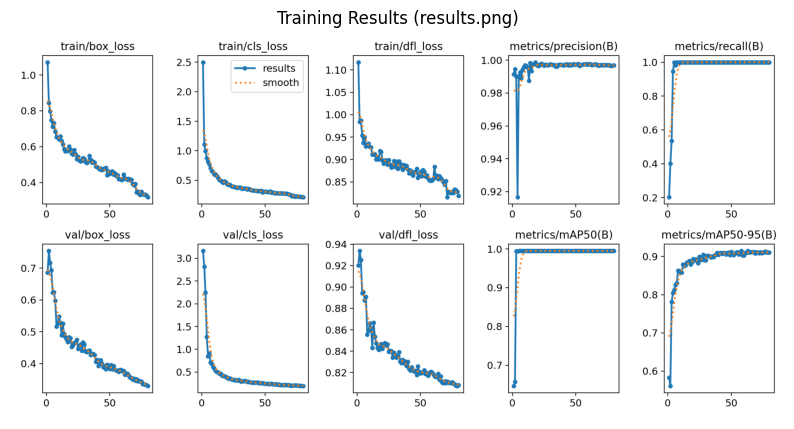

In [18]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import json

# Display results.png
results_png_path = RESULTS_DIR / 'deteccao_escolar' / 'results.png'
if results_png_path.exists():
    plt.figure(figsize=(10, 6))
    plt.imshow(Image.open(results_png_path))
    plt.title('Training Results (results.png)')
    plt.axis('off')
    plt.show()
else:
    print(f"File not found: {results_png_path}")


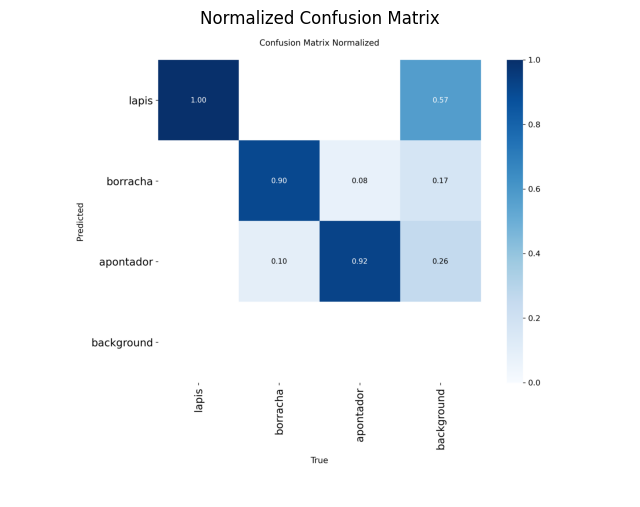

In [19]:
# Display confusion_matrix_normalized.png
confusion_matrix_path = RESULTS_DIR / 'deteccao_escolar' / 'confusion_matrix_normalized.png'
if confusion_matrix_path.exists():
    plt.figure(figsize=(8, 8))
    plt.imshow(Image.open(confusion_matrix_path))
    plt.title('Normalized Confusion Matrix')
    plt.axis('off')
    plt.show()
else:
    print(f"File not found: {confusion_matrix_path}")


In [21]:
# Display metricas_teste.json content
metrics_json_path = RESULTS_DIR / 'metricas_teste.json'
if metrics_json_path.exists():
    with open(metrics_json_path, 'r', encoding='utf-8') as f:
        metrics_data = json.load(f)
    print("Content of metricas_teste.json:")
    print(json.dumps(metrics_data, indent=2))
else:
    print(f"Metrics JSON file not found: {metrics_json_path}")


Content of metricas_teste.json:
{
  "precision": 0.987878767176495,
  "recall": 1.0,
  "map50": 0.995,
  "map50_95": 0.9183164335664338
}


## Exemplo de Detecção com Bounding Boxes

In [30]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import torch

# Define the path to the test images
test_images_path = PROJECT_DIR / 'test' / 'images' # Corrected path

# Get a list of image files from the test set
test_image_files = [f for f in os.listdir(test_images_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if test_image_files:
    # Display up to the first 4 test images with detections
    num_images_to_display = min(4, len(test_image_files))
    plt.figure(figsize=(15, 10))

    for i, image_file in enumerate(test_image_files[:num_images_to_display]):
        sample_image_path = test_images_path / image_file

        print(f"Performing prediction on: {sample_image_path}")

        # Perform prediction and save the annotated image temporarily
        predict_results = best_model.predict(
            source=str(sample_image_path),
            conf=0.25, # Confidence threshold
            imgsz=640,
            save=True,
            project=str(RESULTS_DIR),
            name='demonstracao_deteccao',
            exist_ok=True,
            device=0 if torch.cuda.is_available() else 'cpu'
        )

        # The predict_results is a list, and each item is a Results object
        # The annotated image is usually saved in the save_dir of the Results object
        if predict_results and hasattr(predict_results[0], 'save_dir'):
            predicted_output_dir = Path(predict_results[0].save_dir)
            # The annotated image has the same name as the original and is placed directly in predicted_output_dir
            annotated_image_path = predicted_output_dir / image_file

            if annotated_image_path.exists():
                plt.subplot(2, 2, i + 1) # Arrange in a 2x2 grid
                plt.imshow(Image.open(annotated_image_path))
                plt.title(f'Detection on {image_file}')
                plt.axis('off')
            else:
                print(f"Annotated image not found at expected path: {annotated_image_path}")
                print(f"Please check the directory: {predicted_output_dir} manually.")
        else:
            print(f"Prediction results or save directory not found for {image_file}")

    plt.tight_layout()
    plt.show()
else:
    print(f"No image files found in the test directory: {test_images_path}")

Performing prediction on: /content/drive/MyDrive/FastCamp - Dados Sinteticos/Aula 12 - Trabalho Final/dataset/test/images/escolar_0511.png

image 1/1 /content/drive/MyDrive/FastCamp - Dados Sinteticos/Aula 12 - Trabalho Final/dataset/test/images/escolar_0511.png: 640x640 1 borracha, 7.3ms
Speed: 1.6ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/FastCamp - Dados Sinteticos/Aula 12 - Trabalho Final/dataset/resultados/demonstracao_deteccao
Annotated image not found at expected path: /content/drive/MyDrive/FastCamp - Dados Sinteticos/Aula 12 - Trabalho Final/dataset/resultados/demonstracao_deteccao/escolar_0511.png
Please check the directory: /content/drive/MyDrive/FastCamp - Dados Sinteticos/Aula 12 - Trabalho Final/dataset/resultados/demonstracao_deteccao manually.
Performing prediction on: /content/drive/MyDrive/FastCamp - Dados Sinteticos/Aula 12 - Trabalho Final/dataset/test/images/escolar_0510.png

image 1

<Figure size 1500x1000 with 0 Axes>

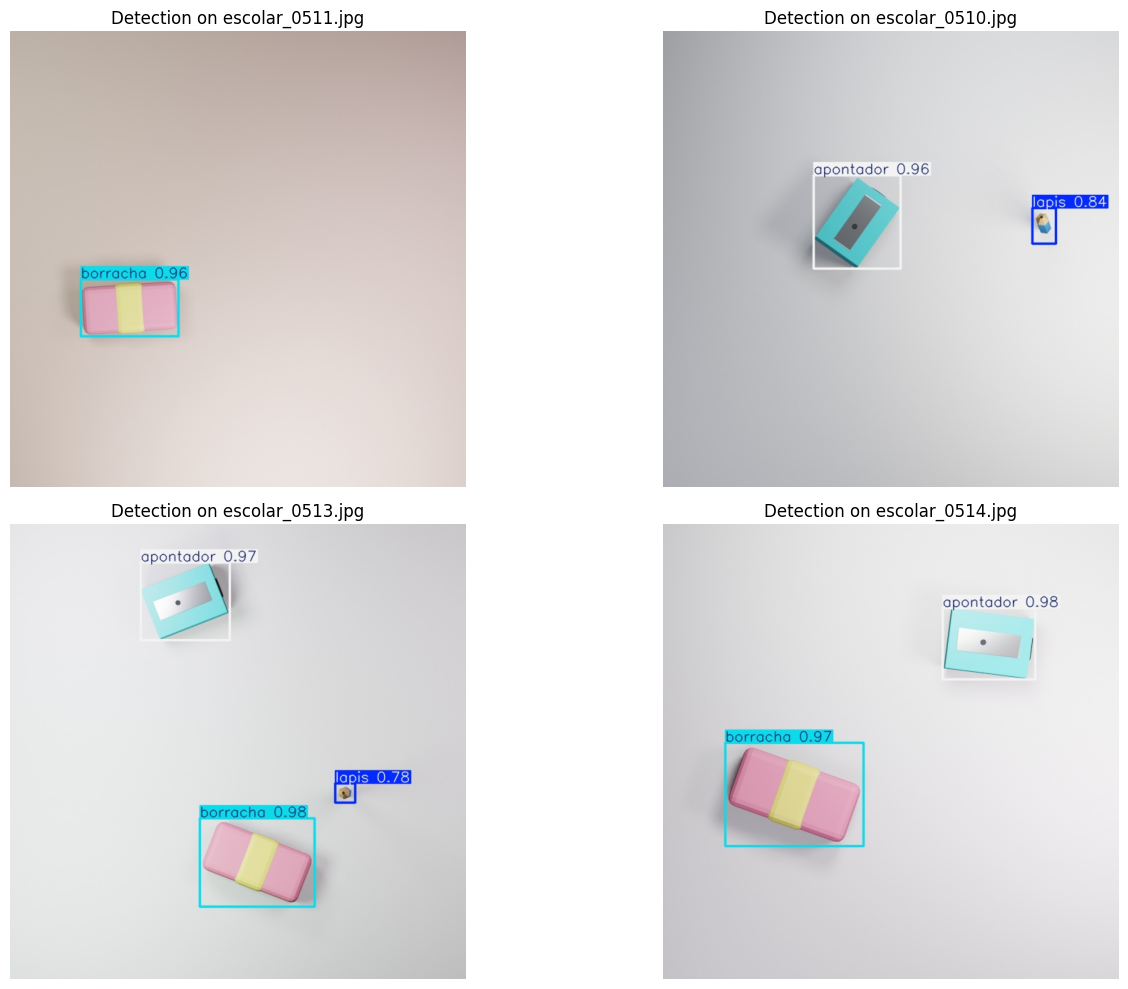

In [32]:
import matplotlib.pyplot as plt
import os
from PIL import Image
from pathlib import Path


annotated_images_dir = RESULTS_DIR / 'demonstracao_deteccao'

if annotated_images_dir.exists():
    annotated_image_files = [f for f in os.listdir(annotated_images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
else:
    annotated_image_files = []
    print(f"Directory not found: {annotated_images_dir}")

if annotated_image_files:
    num_images_to_display = min(4, len(annotated_image_files))
    plt.figure(figsize=(15, 10))

    for i, image_file in enumerate(annotated_image_files[:num_images_to_display]):
        image_path = annotated_images_dir / image_file

        if image_path.exists():
            plt.subplot(2, 2, i + 1) # Arrange in a 2x2 grid
            plt.imshow(Image.open(image_path))
            plt.title(f'Detection on {image_file}')
            plt.axis('off')
        else:
            print(f"Annotated image not found at expected path: {image_path}")

    plt.tight_layout()
    plt.show()
else:
    print(f"No annotated image files found in the directory: {annotated_images_dir}")
    print("Please ensure the previous cell (5bedd38b) was executed successfully to generate the images.")